### Imports

In [1]:
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Running in Google Colab")

    repo_dir = "/content/keyboard_sound"  # fixed absolute path

    if not os.path.exists(repo_dir):
        !git clone https://github.com/ayushma18/keyboard_sound {repo_dir}

    %cd {repo_dir}

    !pip install -r requirements_colab.txt

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import librosa
import os
import random
import seaborn as sns
import pandas as pd
import pickle
import torchaudio
import soundfile as sf

from torchaudio.transforms import TimeMasking, FrequencyMasking
from torchinfo import summary
from tqdm import tqdm
from torchvision import datasets, transforms
from collections import defaultdict
from torchvision.transforms import Compose, ToTensor
from torch.utils.data import DataLoader, Dataset
from scipy.io import wavfile
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

pd.set_option('future.no_silent_downcasting', True)

/tmp/ipykernel_3964/1340087408.py:28: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


In [3]:
data_path= "recordings/segmented/num-merged"  # Contains 0-9 and a-z (36 classes)
unseen_data_path = "recordings/segmented/merged_num_home"  # Unseen environment (different person/setup)
noise_path="model/Noises"
best_model_path = f"model/CNN-Best-{data_path.split('/')[-1]}.pkl"
model_path = f"model/CNN-Final-{data_path.split('/')[-1]}.pkl"

### 📌 Dataset Selection

Available datasets in `Data/segmented/`:
- **`alpha-large`** - 26 classes (a-z only)
- **`alphanum-400`** - 36 classes (0-9 and a-z) ✅ **Currently selected**
- **`alphanum-hard-100`** - 36 classes with harder conditions
- **`alphanum-soft-100`** - 36 classes with softer conditions
- **`num-large`** - 10 classes (0-9 only)

Change `data_path` in the cell below to switch datasets.

### Noise Library Loader & Analyzer

In [4]:
class NoiseLibrary:
    """
    Load and analyze all noise samples for augmentation.
    Stores metadata about each noise: length, RMS level, etc.
    """
    def __init__(self, noise_dir=noise_path):
        self.noise_dir = noise_dir
        self.noises = {
            'city': [],
            'classroom': [],
            'office': [],
            'common': []
        }
        self.noise_metadata = []
        self.load_all_noises()

    def load_all_noises(self):
        """Load all noise files and compute their metadata"""
        print("Loading noise library...")

        # Define category mapping
        categories = {
            'city': 'city',
            'classroom': 'classroom',
            'office': 'office',
            'Common Noises': 'common'
        }

        for category_folder, category_key in categories.items():
            category_path = os.path.join(self.noise_dir, category_folder)
            if not os.path.exists(category_path):
                print(f"Warning: {category_path} not found")
                continue

            for filename in os.listdir(category_path):
                if filename.endswith(('.wav', '.mp3', '.flac', '.ogg')):
                    file_path = os.path.join(category_path, filename)
                    try:
                        # Load audio using soundfile directly (more reliable)
                        import soundfile as sf
                        try:
                            # Try torchaudio first
                            waveform, sr = torchaudio.load(file_path)
                        except (ImportError, RuntimeError):
                            # Fallback to soundfile if torchaudio fails
                            audio_data, sr = sf.read(file_path)
                            waveform = torch.from_numpy(audio_data).float()
                            if waveform.ndim == 1:
                                waveform = waveform.unsqueeze(0)
                            elif waveform.ndim == 2:
                                waveform = waveform.T

                        # Convert to mono if stereo
                        if waveform.shape[0] > 1:
                            waveform = torch.mean(waveform, dim=0, keepdim=True)

                        # Resample to 44.1kHz if needed
                        if sr != 44100:
                            resampler = torchaudio.transforms.Resample(sr, 44100)
                            waveform = resampler(waveform)

                        # Calculate RMS (Root Mean Square) for noise level
                        rms = torch.sqrt(torch.mean(waveform ** 2)).item()

                        noise_info = {
                            'category': category_key,
                            'waveform': waveform,
                            'length': waveform.shape[1],
                            'rms': rms,
                            'filename': filename
                        }

                        self.noises[category_key].append(noise_info)
                        self.noise_metadata.append(noise_info)

                    except Exception as e:
                        print(f"Error loading {file_path}: {e}")

        # Print statistics
        total_noises = len(self.noise_metadata)
        print(f"\n✅ Loaded {total_noises} noise samples:")
        for category, noises in self.noises.items():
            if noises:
                avg_len = np.mean([n['length'] for n in noises])
                avg_rms = np.mean([n['rms'] for n in noises])
                print(f"  - {category}: {len(noises)} samples | Avg length: {avg_len/16000:.2f}s | Avg RMS: {avg_rms:.4f}")

    def get_random_noise(self, category=None):
        """Get a random noise sample, optionally from a specific category"""
        if category and self.noises[category]:
            return random.choice(self.noises[category])
        elif self.noise_metadata:
            return random.choice(self.noise_metadata)
        return None

    def get_noise_segment(self, target_length, category=None):
        """Get a noise segment of specified length"""
        noise_info = self.get_random_noise(category)
        if noise_info is None:
            return None

        waveform = noise_info['waveform']
        noise_length = waveform.shape[1]

        if noise_length >= target_length:
            # Random crop
            start = random.randint(0, noise_length - target_length)
            return waveform[:, start:start + target_length]
        else:
            # Loop the noise to match target length
            repeats = (target_length // noise_length) + 1
            waveform = waveform.repeat(1, repeats)
            return waveform[:, :target_length]

# Initialize global noise library
print("Initializing Noise Library...")
noise_library = NoiseLibrary()
print("✅ Noise Library Ready!\n")

Initializing Noise Library...
Loading noise library...

✅ Loaded 36 noise samples:
  - city: 3 samples | Avg length: 584.13s | Avg RMS: 0.0678
  - classroom: 13 samples | Avg length: 231.23s | Avg RMS: 0.0599
  - office: 3 samples | Avg length: 285.93s | Avg RMS: 0.0172
  - common: 17 samples | Avg length: 156.71s | Avg RMS: 0.0356
✅ Noise Library Ready!



### SNR-Based Noise Addition Functions

In [5]:
def calculate_rms(waveform):
    """Calculate Root Mean Square (RMS) of waveform"""
    return torch.sqrt(torch.mean(waveform ** 2))

def add_noise_snr(signal, noise, target_snr_db):
    """
    Add noise to signal at a specific SNR (Signal-to-Noise Ratio) level.

    Args:
        signal: Clean audio signal (torch.Tensor)
        noise: Noise audio (torch.Tensor)
        target_snr_db: Target SNR in decibels (5-20 dB recommended)
                      5 dB = very noisy, 10 dB = realistic, 20 dB = light noise

    Returns:
        Noisy signal with specified SNR
    """
    # Calculate RMS of signal and noise
    signal_rms = calculate_rms(signal)
    noise_rms = calculate_rms(noise)

    # Calculate required noise scaling factor
    # SNR = 20 * log10(signal_rms / noise_rms)
    # noise_rms_target = signal_rms / (10 ^ (SNR/20))
    snr_linear = 10 ** (target_snr_db / 20.0)
    target_noise_rms = signal_rms / snr_linear

    # Scale noise to achieve target SNR
    scaling_factor = target_noise_rms / (noise_rms + 1e-10)
    scaled_noise = noise * scaling_factor

    # Add noise to signal
    noisy_signal = signal + scaled_noise

    return noisy_signal

def add_white_noise_snr(signal, target_snr_db):
    """
    Add white (uniform) noise at specified SNR

    Args:
        signal: Clean audio signal
        target_snr_db: Target SNR in dB

    Returns:
        Signal with white noise
    """
    # Generate white noise with same shape as signal
    noise = torch.randn_like(signal)
    return add_noise_snr(signal, noise, target_snr_db)

def add_gaussian_noise_snr(signal, target_snr_db):
    """
    Add Gaussian noise at specified SNR

    Args:
        signal: Clean audio signal
        target_snr_db: Target SNR in dB

    Returns:
        Signal with Gaussian noise
    """
    # Generate Gaussian noise
    noise = torch.normal(mean=0, std=0.1, size=signal.shape)
    return add_noise_snr(signal, noise, target_snr_db)

def reduce_volume_db(signal, db_reduction):
    """
    Reduce signal volume by specified dB (simulates microphone placed further away)

    Args:
        signal: Audio signal
        db_reduction: dB to reduce (positive value, e.g., 6 dB, 10 dB, 15 dB)

    Returns:
        Quieter signal
    """
    # Convert dB to linear scale
    # dB = 20 * log10(amplitude_ratio)
    amplitude_ratio = 10 ** (-db_reduction / 20.0)
    return signal * amplitude_ratio

### Hybrid Noise Augmentation Pipeline

In [6]:
class AggressiveMultiVariationAugmentation:
    """
    AGGRESSIVE multi-variation augmentation for training robustness.

    Applies MANY VARIATIONS with both small and large noise:
    - Real ambient noise (all 4 categories)
    - White noise
    - Gaussian noise
    - Mixed combinations (real+white, real+gaussian)
    - Wide SNR range: 5-30 dB (from noisy to nearly clean)
    - Volume variations
    - Multiple augmentations per sample

    NO CLEAN SAMPLES - Always augment to force model robustness!
    """
    def __init__(self, noise_library,
                 snr_range=(5, 30),           # Min 5dB to avoid signal cancellation
                 volume_reduction_prob=0.4,   # 40% chance
                 volume_reduction_range=(2, 15),  # 2-15 dB reduction
                 multi_aug_prob=0.3):         # 30% chance of multiple augmentations
        self.noise_library = noise_library
        self.snr_range = snr_range
        self.volume_reduction_prob = volume_reduction_prob
        self.volume_reduction_range = volume_reduction_range
        self.multi_aug_prob = multi_aug_prob

        self.strategies = [
            'real_city',
            'real_office',
            'real_classroom',
            'real_common',
            'white',
            'gaussian',
            'mixed_real_white',
            'mixed_real_gaussian',
            'real_random',
        ]

        print(f"🔥 AGGRESSIVE Multi-Variation Augmentation Configuration:")
        print(f"  ├─ Strategies: {len(self.strategies)} different noise types")
        print(f"  ├─ SNR range: {snr_range[0]}-{snr_range[1]} dB")
        print(f"  ├─ Volume reduction: {volume_reduction_prob*100:.0f}% chance")
        print(f"  ├─ Volume reduction range: {volume_reduction_range[0]}-{volume_reduction_range[1]} dB")
        print(f"  ├─ Multi-augmentation: {multi_aug_prob*100:.0f}% chance")
        print(f"  └─ Clean samples: 0% (ALWAYS AUGMENTED!)")

    def apply_augmentation(self, signal, strategy, snr):
        """Apply a single augmentation strategy"""
        signal_length = signal.shape[1] if signal.dim() > 1 else signal.shape[0]

        if strategy == 'real_city':
            noise_segment = self.noise_library.get_noise_segment(signal_length, 'city')
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)

        elif strategy == 'real_office':
            noise_segment = self.noise_library.get_noise_segment(signal_length, 'office')
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)

        elif strategy == 'real_classroom':
            noise_segment = self.noise_library.get_noise_segment(signal_length, 'classroom')
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)

        elif strategy == 'real_common':
            noise_segment = self.noise_library.get_noise_segment(signal_length, 'common')
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)

        elif strategy == 'real_random':
            noise_segment = self.noise_library.get_noise_segment(signal_length, None)
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)

        elif strategy == 'white':
            signal = add_white_noise_snr(signal, snr)

        elif strategy == 'gaussian':
            signal = add_gaussian_noise_snr(signal, snr)

        elif strategy == 'mixed_real_white':
            noise_segment = self.noise_library.get_noise_segment(signal_length, None)
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)
            signal = add_white_noise_snr(signal, snr + 5)

        elif strategy == 'mixed_real_gaussian':
            noise_segment = self.noise_library.get_noise_segment(signal_length, None)
            if noise_segment is not None:
                if noise_segment.shape[0] != signal.shape[0]:
                    noise_segment = noise_segment[:signal.shape[0], :]
                signal = add_noise_snr(signal, noise_segment, snr)
            signal = add_gaussian_noise_snr(signal, snr + 5)

        return signal

    def __call__(self, signal):
        signal = signal.clone()

        target_snr = random.uniform(self.snr_range[0], self.snr_range[1])
        strategy = random.choice(self.strategies)
        signal = self.apply_augmentation(signal, strategy, target_snr)

        if random.random() < self.multi_aug_prob:
            second_snr = random.uniform(max(target_snr, 10), 30)
            second_strategy = random.choice(['white', 'gaussian'])
            signal = self.apply_augmentation(signal, second_strategy, second_snr)

        if random.random() < self.volume_reduction_prob:
            db_reduction = random.uniform(
                self.volume_reduction_range[0],
                self.volume_reduction_range[1]
            )
            signal = reduce_volume_db(signal, db_reduction)

        return signal

# Initialize AGGRESSIVE multi-variation augmentation
print("\n" + "="*70)
print("🔥 INITIALIZING AGGRESSIVE MULTI-VARIATION AUGMENTATION FOR TRAINING")
print("="*70)
aggressive_aug = AggressiveMultiVariationAugmentation(
    noise_library=noise_library,
    snr_range=(5, 30),              # Min 5dB prevents signal cancellation → NaN
    volume_reduction_prob=0.4,
    volume_reduction_range=(2, 15),
    multi_aug_prob=0.3
)
print("="*70 + "\n")



🔥 INITIALIZING AGGRESSIVE MULTI-VARIATION AUGMENTATION FOR TRAINING
🔥 AGGRESSIVE Multi-Variation Augmentation Configuration:
  ├─ Strategies: 9 different noise types
  ├─ SNR range: 5-30 dB
  ├─ Volume reduction: 40% chance
  ├─ Volume reduction range: 2-15 dB
  ├─ Multi-augmentation: 30% chance
  └─ Clean samples: 0% (ALWAYS AUGMENTED!)



### Loading data

In [7]:
class AudioDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.n_samples = 0
        self.dataset = []
        self.labels = set()
        self.label_map = {}  # maps raw label string -> contiguous index
        self.load_audio_files(self.data_dir)

    def load_audio_files(self, path: str):
        # First pass: collect all valid label strings
        raw_labels = set()
        for dirname, _, filenames in os.walk(path):
            label = os.path.basename(dirname)
            if filenames and (('0' <= label <= '9') or ('a' <= label <= 'z')):
                raw_labels.add(label)

        # Build contiguous label map (sorted for consistency)
        for idx, label in enumerate(sorted(raw_labels)):
            self.label_map[label] = idx

        # Second pass: load files
        for dirname, _, filenames in os.walk(path):
            for filename in filenames:
                file_path = os.path.join(dirname, filename)
                label = os.path.basename(dirname)

                if label not in self.label_map:
                    continue

                label_index = self.label_map[label]
                label_tensor = torch.tensor(label_index)
                self.labels.add(label_tensor.item())

                # Load audio using soundfile directly (more reliable than torchaudio.load)
                import soundfile as sf
                try:
                    # Try torchaudio first for compatibility
                    waveform, sample_rate = torchaudio.load(file_path)
                except (ImportError, RuntimeError):
                    # Fallback to soundfile if torchaudio fails
                    audio_data, sample_rate = sf.read(file_path)
                    # Convert to torch tensor and add channel dimension if needed
                    waveform = torch.from_numpy(audio_data).float()
                    if waveform.ndim == 1:
                        waveform = waveform.unsqueeze(0)  # Add channel dimension
                    elif waveform.ndim == 2:
                        waveform = waveform.T  # Transpose to (channels, samples)

                self.n_samples += 1
                self.dataset.append((waveform, label_tensor))  # Store RAW audio

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        waveform, label = self.dataset[idx]
        # Apply transforms if provided (CRITICAL FIX!)
        if self.transform is not None:
            waveform = self.transform(waveform)
        return waveform, label

    def num_classes(self):
        return len(self.labels)


In [8]:
# Configure audio loading backend
# In newer torchaudio versions, soundfile is used automatically if installed
# The set_audio_backend API was removed - backends are auto-selected
print("ℹ️  torchaudio will auto-select backend (soundfile is installed)")

sample_rate = 44100
to_mel_spectrogram = torchaudio.transforms.MelSpectrogram(sample_rate, n_mels=64, hop_length=300, n_fft=2048, win_length=1024)
mel_spectrogram_to_numpy = lambda spectrogram: spectrogram.clamp(min=1e-9).log2()[0,:,:].numpy()
transforms = Compose([to_mel_spectrogram, mel_spectrogram_to_numpy, ToTensor()])
dataset = AudioDataset(data_path, None)  # Store raw audio; transforms applied by TrainingDataset
print("number of classes:", dataset.num_classes())


ℹ️  torchaudio will auto-select backend (soundfile is installed)
number of classes: 10


In [9]:
# 🔍 Diagnostic: Check if dataset path exists and has files
import os

print("📂 Checking dataset path...")
print(f"   data_path = '{data_path}'")
print(f"   Path exists: {os.path.exists(data_path)}")

if os.path.exists(data_path):
    # List subdirectories (should be letter folders)
    subdirs = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"   Found {len(subdirs)} subdirectories: {sorted(subdirs)[:10]}...")
    
    # Count total audio files
    total_files = 0
    for subdir in subdirs:
        subdir_path = os.path.join(data_path, subdir)
        files = [f for f in os.listdir(subdir_path) if f.endswith('.wav')]
        total_files += len(files)
    
    print(f"   Total .wav files: {total_files}")
    
    if total_files == 0:
        print("   ⚠️  No .wav files found! Check if audio files are present.")
else:
    print(f"   ❌ Path does NOT exist!")
    print(f"   Current working directory: {os.getcwd()}")
    print(f"   \n💡 Suggestion: The correct path should be 'Data/segmented/alpha-large'")
    print(f"   Run cell 4 again to set the correct path, then re-run this cell.")

📂 Checking dataset path...
   data_path = 'recordings/segmented/num-merged'
   Path exists: True
   Found 10 subdirectories: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']...
   Total .wav files: 4890


In [10]:
targets = [data[1] for data in dataset]

train_indices, tmp_indices = train_test_split(
    range(len(dataset)),
    test_size=0.3,
    stratify=targets
)

val_indices, test_indices = train_test_split(
    tmp_indices,
    test_size=0.33,
    stratify=[targets[i] for i in tmp_indices]
)

init_train_set = torch.utils.data.Subset(dataset, train_indices)
init_val_set = torch.utils.data.Subset(dataset, val_indices)
init_test_set = torch.utils.data.Subset(dataset, test_indices)

print("Sample rate:", sample_rate)
print(f"Train set size: {len(init_train_set)}, Validation set size: {len(init_val_set)}, Test set size: {len(init_test_set)}")

Sample rate: 44100
Train set size: 3423, Validation set size: 982, Test set size: 485


### Data Augmentation - AGGRESSIVE Multi-Variation Training


In [11]:
class TrainingDataset(Dataset):
    def __init__(self, base_dataset, transformations):
        super(TrainingDataset, self).__init__()
        self.base = base_dataset
        self.transformations = transformations

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        waveform, label = self.base[idx]
        return self.transformations(waveform), label

In [12]:
class TimeShifting:
    """Time shifting augmentation with increased shift range for better robustness"""
    def __init__(self, shift_ratio=0.5):
        """
        Args:
            shift_ratio: Ratio of audio length to use as max shift (default 0.5 = 50%)
                        Increased from 0.3 to 0.5 for better temporal variation
        """
        self.shift_ratio = shift_ratio

    def __call__(self, samples):
        if isinstance(samples, torch.Tensor):
            samples = samples.numpy()

        # Increased shift range from 30% to 50% for better augmentation
        shift = int(samples.shape[1] * self.shift_ratio)
        random_shift = random.randint(0, shift)

        data_roll = np.zeros_like(samples)
        for ch in range(samples.shape[0]):
            data_roll[ch] = np.roll(samples[ch], random_shift)

        return torch.tensor(data_roll)

In [13]:
# 🔥 AGGRESSIVE Multi-Variation Augmentation Pipeline for Hard Training
# Combines: Aggressive Multi-Noise + Time Shifting + HEAVY Spectrogram Masking
# Goal: Force model to learn from MAXIMUM variation (small to large noise)
aug_transforms = Compose([
    aggressive_aug,                  # Apply aggressive multi-variation noise FIRST
    TimeShifting(shift_ratio=0.5),   # Time shifting (50%)
    to_mel_spectrogram,              # Convert to mel spectrogram
    mel_spectrogram_to_numpy,        # Convert to numpy
    ToTensor(),                      # Convert to tensor
    # HEAVY spectrogram masking for additional robustness
    # FrequencyMasking(10),            # Increased from 7 to 10
    # TimeMasking(10),                 # Increased from 7 to 10
    # FrequencyMasking(10),            # Second pass
    # TimeMasking(10),                 # Second pass
    # FrequencyMasking(5),             # Third pass (lighter)
    # TimeMasking(5),                  # Third pass (lighter)
])

# Training datasets with augmentation and without
train_set = TrainingDataset(init_train_set, aug_transforms)
train_set_no_aug = TrainingDataset(init_train_set, transforms)
val_set = TrainingDataset(init_val_set, transforms)
test_set = TrainingDataset(init_test_set, transforms)

print(f"\n" + "="*70)
print("✅ AGGRESSIVE TRAINING DATASETS CREATED")
print("="*70)
print(f"  ├─ Train (AGGRESSIVE augmentation): {len(train_set)} samples")
print(f"  │   └─ Each sample gets:")
print(f"  │       • One of 9 noise strategies (SNR 0-30dB)")
print(f"  │       • 30% chance of double augmentation")
print(f"  │       • 40% chance of volume reduction")
print(f"  │       • Time shifting (50% range)")
print(f"  │       • 6 layers of spectrogram masking")
print(f"  │")
print(f"  ├─ Train (no augmentation): {len(train_set_no_aug)} samples")
print(f"  ├─ Validation (no augmentation): {len(val_set)} samples")
print(f"  └─ Test (no augmentation): {len(test_set)} samples")
print("="*70)
print("\n💪 Model will be trained on MAXIMUM variation for robustness!")
print("="*70 + "\n")



✅ AGGRESSIVE TRAINING DATASETS CREATED
  ├─ Train (AGGRESSIVE augmentation): 3423 samples
  │   └─ Each sample gets:
  │       • One of 9 noise strategies (SNR 0-30dB)
  │       • 30% chance of double augmentation
  │       • 40% chance of volume reduction
  │       • Time shifting (50% range)
  │       • 6 layers of spectrogram masking
  │
  ├─ Train (no augmentation): 3423 samples
  ├─ Validation (no augmentation): 982 samples
  └─ Test (no augmentation): 485 samples

💪 Model will be trained on MAXIMUM variation for robustness!



### 🔍 Test Noise Augmentation (Optional - Run to Verify)

In [14]:
# Load a sample waveform for testing noise augmentation
from IPython.display import Audio, display

# Create temp directory if it doesn't exist
temp_audio_dir = '/tmp/noise_samples'
os.makedirs(temp_audio_dir, exist_ok=True)

# Get a sample from the training set (before augmentation)
test_waveform, test_label = init_train_set[0]
print(f"✅ Loaded test sample:")
print(f"   Label index: {test_label.item()}")
print(f"   Waveform shape: {test_waveform.shape}")
print(f"   Sample rate: {sample_rate} Hz")
print(f"   Duration: {test_waveform.shape[1]/sample_rate:.3f} seconds")
print(f"   RMS: {calculate_rms(test_waveform).item():.6f}")

# Save and play original clean audio
clean_audio = test_waveform.numpy()[0] if test_waveform.ndim > 1 else test_waveform.numpy()
clean_path = os.path.join(temp_audio_dir, 'clean_original.wav')
sf.write(clean_path, clean_audio, sample_rate)

print("\n1️⃣  ORIGINAL CLEAN AUDIO")
display(Audio(clean_path, rate=sample_rate))

✅ Loaded test sample:
   Label index: 7
   Waveform shape: torch.Size([2, 18963])
   Sample rate: 44100 Hz
   Duration: 0.430 seconds
   RMS: 0.004501

1️⃣  ORIGINAL CLEAN AUDIO


In [15]:
# 5. Save and play VOLUME REDUCED (simulating far microphone)
volume_reduced_6db = reduce_volume_db(test_waveform, db_reduction=6)
volume_reduced_12db = reduce_volume_db(test_waveform, db_reduction=12)

vol_6db_audio = volume_reduced_6db.numpy()[0] if volume_reduced_6db.ndim > 1 else volume_reduced_6db.numpy()
vol_12db_audio = volume_reduced_12db.numpy()[0] if volume_reduced_12db.ndim > 1 else volume_reduced_12db.numpy()

vol_6db_path = os.path.join(temp_audio_dir, 'volume_reduced_6db.wav')
vol_12db_path = os.path.join(temp_audio_dir, 'volume_reduced_12db.wav')
sf.write(vol_6db_path, vol_6db_audio, sample_rate)
sf.write(vol_12db_path, vol_12db_audio, sample_rate)

print("\n5️⃣  VOLUME REDUCED (Distant Microphone)")
print(f"   🔉 -6 dB reduction - RMS: {calculate_rms(volume_reduced_6db).item():.6f}")
display(Audio(vol_6db_path, rate=sample_rate))
print(f"   🔉 -12 dB reduction - RMS: {calculate_rms(volume_reduced_12db).item():.6f}")
display(Audio(vol_12db_path, rate=sample_rate))


5️⃣  VOLUME REDUCED (Distant Microphone)
   🔉 -6 dB reduction - RMS: 0.002256


   🔉 -12 dB reduction - RMS: 0.001131


In [16]:
# 4. Save and play GAUSSIAN NOISE
gaussian_noise_10db = add_gaussian_noise_snr(test_waveform, target_snr_db=10)
gaussian_noise_5db = add_gaussian_noise_snr(test_waveform, target_snr_db=5)

gaussian_10db_audio = gaussian_noise_10db.numpy()[0] if gaussian_noise_10db.ndim > 1 else gaussian_noise_10db.numpy()
gaussian_5db_audio = gaussian_noise_5db.numpy()[0] if gaussian_noise_5db.ndim > 1 else gaussian_noise_5db.numpy()

gaussian_10db_path = os.path.join(temp_audio_dir, 'gaussian_noise_10db.wav')
gaussian_5db_path = os.path.join(temp_audio_dir, 'gaussian_noise_5db.wav')
sf.write(gaussian_10db_path, gaussian_10db_audio, sample_rate)
sf.write(gaussian_5db_path, gaussian_5db_audio, sample_rate)

print("\n4️⃣  GAUSSIAN NOISE")
print(f"   🔊 Light noise (10 dB SNR) - RMS: {calculate_rms(gaussian_noise_10db).item():.6f}")
display(Audio(gaussian_10db_path, rate=sample_rate))
print(f"   🔊 Heavy noise (5 dB SNR) - RMS: {calculate_rms(gaussian_noise_5db).item():.6f}")
display(Audio(gaussian_5db_path, rate=sample_rate))


4️⃣  GAUSSIAN NOISE
   🔊 Light noise (10 dB SNR) - RMS: 0.004726


   🔊 Heavy noise (5 dB SNR) - RMS: 0.005149


In [17]:
# 3. Save and play WHITE NOISE
white_noise_10db = add_white_noise_snr(test_waveform, target_snr_db=10)
white_noise_5db = add_white_noise_snr(test_waveform, target_snr_db=5)

white_10db_audio = white_noise_10db.numpy()[0] if white_noise_10db.ndim > 1 else white_noise_10db.numpy()
white_5db_audio = white_noise_5db.numpy()[0] if white_noise_5db.ndim > 1 else white_noise_5db.numpy()

white_10db_path = os.path.join(temp_audio_dir, 'white_noise_10db.wav')
white_5db_path = os.path.join(temp_audio_dir, 'white_noise_5db.wav')
sf.write(white_10db_path, white_10db_audio, sample_rate)
sf.write(white_5db_path, white_5db_audio, sample_rate)

print("\n3️⃣  WHITE NOISE (Uniform Random)")
print(f"   🔊 Light noise (10 dB SNR) - RMS: {calculate_rms(white_noise_10db).item():.6f}")
display(Audio(white_10db_path, rate=sample_rate))
print(f"   🔊 Heavy noise (5 dB SNR) - RMS: {calculate_rms(white_noise_5db).item():.6f}")
display(Audio(white_5db_path, rate=sample_rate))


3️⃣  WHITE NOISE (Uniform Random)
   🔊 Light noise (10 dB SNR) - RMS: 0.004711


   🔊 Heavy noise (5 dB SNR) - RMS: 0.005159


In [18]:
# 2. Save and play REAL AMBIENT NOISE (Office/City/Classroom)
# Get noise segments
noise_segment_10db = noise_library.get_noise_segment(test_waveform.shape[1])
noise_segment_5db = noise_library.get_noise_segment(test_waveform.shape[1])

# Check if noise library has samples
if noise_segment_10db is None or noise_segment_5db is None:
    print("\n2️⃣  REAL AMBIENT NOISE (Office/City/Classroom)")
    print("   ⚠️  No noise samples found in the noise library.")
    print(f"   Noise path: {noise_path}")
    print("   Make sure noise files exist in: model/Noises/{city,classroom,office,Common Noises}/")
    print("   Skipping real noise examples...")
else:
    real_noise_10db = add_noise_snr(test_waveform, noise_segment_10db, target_snr_db=10)
    real_noise_5db = add_noise_snr(test_waveform, noise_segment_5db, target_snr_db=5)

    # Convert to numpy
    real_10db_audio = real_noise_10db.numpy()[0] if real_noise_10db.ndim > 1 else real_noise_10db.numpy()
    real_5db_audio = real_noise_5db.numpy()[0] if real_noise_5db.ndim > 1 else real_noise_5db.numpy()

    # Save
    real_10db_path = os.path.join(temp_audio_dir, 'real_ambient_10db.wav')
    real_5db_path = os.path.join(temp_audio_dir, 'real_ambient_5db.wav')
    sf.write(real_10db_path, real_10db_audio, sample_rate)
    sf.write(real_5db_path, real_5db_audio, sample_rate)

    print("\n2️⃣  REAL AMBIENT NOISE (Office/City/Classroom)")
    print(f"   🔊 Light noise (10 dB SNR) - RMS: {calculate_rms(real_noise_10db).item():.6f}")
    display(Audio(real_10db_path, rate=sample_rate))
    print(f"   🔊 Heavy noise (5 dB SNR) - RMS: {calculate_rms(real_noise_5db).item():.6f}")
    display(Audio(real_5db_path, rate=sample_rate))


2️⃣  REAL AMBIENT NOISE (Office/City/Classroom)
   🔊 Light noise (10 dB SNR) - RMS: 0.004708


   🔊 Heavy noise (5 dB SNR) - RMS: 0.005159


### Visualization

torch.Size([64, 64])


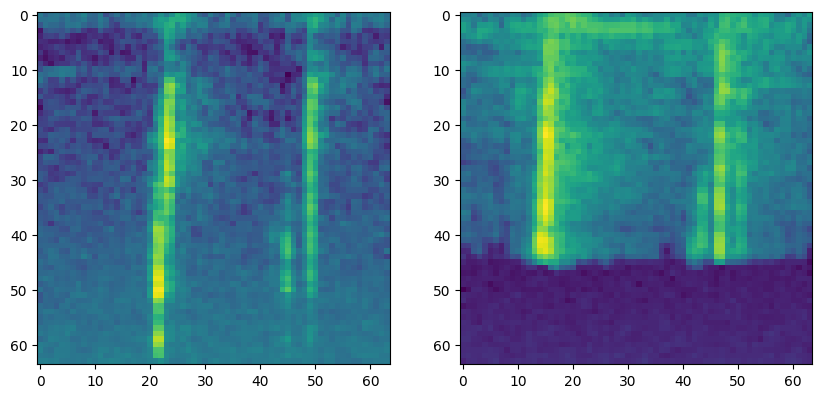

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(train_set[3][0][0], cmap='viridis')
ax2.imshow(val_set[0][0][0], cmap='viridis')
print(train_set[0][0][0].shape)
ax1.grid(False)
ax2.grid(False)
plt.show()

### CNN Model

In [20]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, stride=1, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [21]:
class CNN(nn.Module):
    def __init__(self, num_classes=36):
        super().__init__()

        self.conv1 = ConvBlock(1, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout2d(0.25)

        self.conv2 = ConvBlock(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout2 = nn.Dropout2d(0.25)

        self.conv3 = ConvBlock(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout3 = nn.Dropout2d(0.3)

        self.conv4 = ConvBlock(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout4 = nn.Dropout2d(0.3)

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.pool1(x)
        x = self.dropout1(x)

        x = self.conv2(x)
        x = self.pool2(x)
        x = self.dropout2(x)

        x = self.conv3(x)
        x = self.pool3(x)
        x = self.dropout3(x)

        x = self.conv4(x)
        x = self.pool4(x)
        x = self.dropout4(x)

        x = self.global_pool(x)
        x = self.fc(x)

        return x


In [22]:
model = CNN(num_classes=dataset.num_classes())

In [23]:
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [24]:
def get_device():
    if torch.cuda.is_available():
        try:
            torch.zeros(1).cuda()
            return 'cuda'
        except Exception as e:
            print(f"⚠️  CUDA available but unusable ({e}), falling back to CPU")
    return 'cpu'

device = get_device()

model.apply(init_weights)
model.to(device)

print("Number of parameters: {:,}".format(sum(p.numel() for p in model.parameters())))
print(f"Device: {device}")

summary(model, input_size=(1, 1, 64, 64))


Number of parameters: 4,853,578
Device: cuda


Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 10]                   --
├─ConvBlock: 1-1                         [1, 64, 64, 64]           --
│    └─Sequential: 2-1                   [1, 64, 64, 64]           --
│    │    └─Conv2d: 3-1                  [1, 64, 64, 64]           640
│    │    └─BatchNorm2d: 3-2             [1, 64, 64, 64]           128
│    │    └─ReLU: 3-3                    [1, 64, 64, 64]           --
│    │    └─Conv2d: 3-4                  [1, 64, 64, 64]           36,928
│    │    └─BatchNorm2d: 3-5             [1, 64, 64, 64]           128
│    │    └─ReLU: 3-6                    [1, 64, 64, 64]           --
├─MaxPool2d: 1-2                         [1, 64, 32, 32]           --
├─Dropout2d: 1-3                         [1, 64, 32, 32]           --
├─ConvBlock: 1-4                         [1, 128, 32, 32]          --
│    └─Sequential: 2-2                   [1, 128, 32, 32]          --
│    │  

### Training setup

In [25]:

train_dataloader = torch.utils.data.DataLoader(
    train_set,
    batch_size=32,
    shuffle=True
)

val_dataloader = torch.utils.data.DataLoader(
    val_set,
    batch_size=32,
    shuffle=False
)

test_dataloader = torch.utils.data.DataLoader(
    test_set,
    batch_size=32,
    shuffle=False
)

# Unseen environment — evaluated every epoch to track cross-environment generalisation
unseen_dataset = AudioDataset(unseen_data_path, None)
unseen_set = TrainingDataset(unseen_dataset, transforms)
unseen_dataloader = torch.utils.data.DataLoader(
    unseen_set,
    batch_size=32,
    shuffle=False
)

print(f"✅ Dataloaders ready")
print(f"   Train   : {len(train_set):>5} samples  ({data_path.split('/')[-1]})")
print(f"   Val     : {len(val_set):>5} samples  ({data_path.split('/')[-1]})")
print(f"   Test    : {len(test_set):>5} samples  ({data_path.split('/')[-1]})")
print(f"   Unseen  : {len(unseen_set):>5} samples  ({unseen_data_path.split('/')[-1]})")


✅ Dataloaders ready
   Train   :  3423 samples  (num-merged)
   Val     :   982 samples  (num-merged)
   Test    :   485 samples  (num-merged)
   Unseen  :  1550 samples  (merged_num_home)


In [26]:
cost = nn.CrossEntropyLoss()

learning_rate = 1e-3
weight_decay = 1e-4
max_epochs = 1200  # Maximum epochs (safety limit)

# Early Stopping Parameters
early_stopping_patience = 50  # Stop if no improvement for 50 epochs
early_stopping_min_delta = 0.001  # Minimum change to qualify as improvement

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

### Training

In [27]:

def plot_results(train_losses, train_accuracies, val_losses, val_accuracies, unseen_accuracies=None):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.title("Loss")
    plt.plot(train_losses)
    plt.plot(val_losses)
    plt.legend(["Training loss", "Validation loss"], loc="best")

    plt.subplot(1, 2, 2)
    plt.title("Accuracy")
    plt.plot(train_accuracies)
    plt.plot(val_accuracies)
    legend_labels = ["Training accuracy", "Validation accuracy"]
    if unseen_accuracies is not None:
        plt.plot(unseen_accuracies, linestyle='--', color='orange')
        legend_labels.append("Unseen env accuracy")
    plt.legend(legend_labels, loc="best")
    plt.show()


In [28]:
def save_model(model, path):
    torch.save(model.state_dict(), path)

class EarlyStopping:
    """Early stopping to stop training when validation loss doesn't improve"""
    def __init__(self, patience=50, min_delta=0.001, mode='min'):
        """
        Args:
            patience: Number of epochs to wait after last improvement
            min_delta: Minimum change in monitored metric to qualify as improvement
            mode: 'min' for loss (lower is better), 'max' for accuracy (higher is better)
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.improved = False
        
    def __call__(self, current_score):
        """Check if training should stop"""
        self.improved = False
        
        if self.best_score is None:
            self.best_score = current_score
            self.improved = True
        elif self.mode == 'min':
            if current_score < self.best_score - self.min_delta:
                self.best_score = current_score
                self.counter = 0
                self.improved = True
            else:
                self.counter += 1
        else:  # mode == 'max'
            if current_score > self.best_score + self.min_delta:
                self.best_score = current_score
                self.counter = 0
                self.improved = True
            else:
                self.counter += 1
        
        if self.counter >= self.patience:
            self.early_stop = True
            
        return self.early_stop

🚀 Starting training with early stopping:
   • Max epochs: 1200
   • Early stopping patience: 50 epochs
   • Min delta: 0.001
   • Monitoring: Validation Loss
   • Unseen env: merged_num_home

Epoch [1/1200], Train Loss: 2.6226, Train Acc: 0.1034, Val Loss: 2.2965, Val Acc: 0.1181, Unseen Acc: 0.1052
  ✓ Best model saved with validation accuracy: 0.1181
Epoch [2/1200], Train Loss: 2.3558, Train Acc: 0.1002, Val Loss: 2.2893, Val Acc: 0.1497, Unseen Acc: 0.0742
  ✓ Best model saved with validation accuracy: 0.1497
Epoch [3/1200], Train Loss: 2.3293, Train Acc: 0.1014, Val Loss: 2.3022, Val Acc: 0.1130, Unseen Acc: 0.1097
Epoch [4/1200], Train Loss: 2.3165, Train Acc: 0.1031, Val Loss: 2.2903, Val Acc: 0.1650, Unseen Acc: 0.1400
  ✓ Best model saved with validation accuracy: 0.1650
Epoch [5/1200], Train Loss: 2.3093, Train Acc: 0.1066, Val Loss: 2.2896, Val Acc: 0.0957, Unseen Acc: 0.1135
Epoch [6/1200], Train Loss: 2.3057, Train Acc: 0.0967, Val Loss: 2.2937, Val Acc: 0.1640, Unseen Acc:

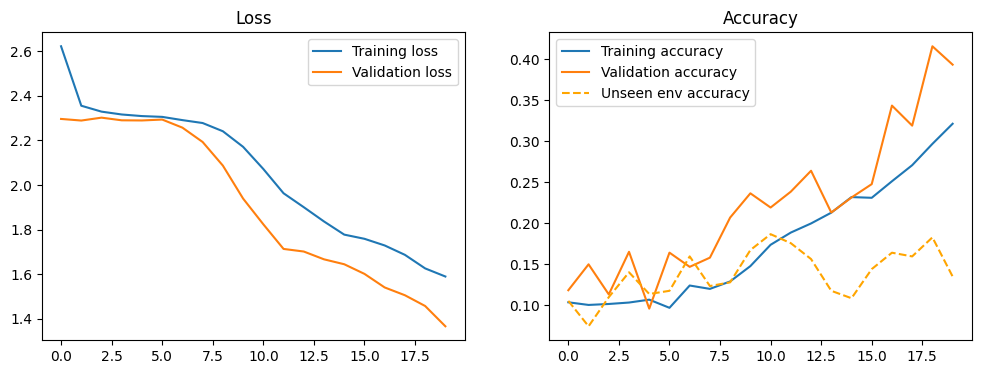

Epoch [21/1200], Train Loss: 1.5330, Train Acc: 0.3380, Val Loss: 1.2775, Val Acc: 0.4450, Unseen Acc: 0.1529
  ✓ Best model saved with validation accuracy: 0.4450
Epoch [22/1200], Train Loss: 1.4491, Train Acc: 0.3731, Val Loss: 1.1822, Val Acc: 0.4837, Unseen Acc: 0.1781
  ✓ Best model saved with validation accuracy: 0.4837
Epoch [23/1200], Train Loss: 1.3823, Train Acc: 0.3880, Val Loss: 1.0661, Val Acc: 0.5051, Unseen Acc: 0.1090
  ✓ Best model saved with validation accuracy: 0.5051
Epoch [24/1200], Train Loss: 1.2903, Train Acc: 0.4300, Val Loss: 0.9706, Val Acc: 0.5132, Unseen Acc: 0.1471
  ✓ Best model saved with validation accuracy: 0.5132
Epoch [25/1200], Train Loss: 1.2156, Train Acc: 0.4625, Val Loss: 0.8997, Val Acc: 0.5988, Unseen Acc: 0.1645
  ✓ Best model saved with validation accuracy: 0.5988
Epoch [26/1200], Train Loss: 1.1629, Train Acc: 0.4908, Val Loss: 0.8221, Val Acc: 0.5998, Unseen Acc: 0.1677
  ✓ Best model saved with validation accuracy: 0.5998
Epoch [27/1200],

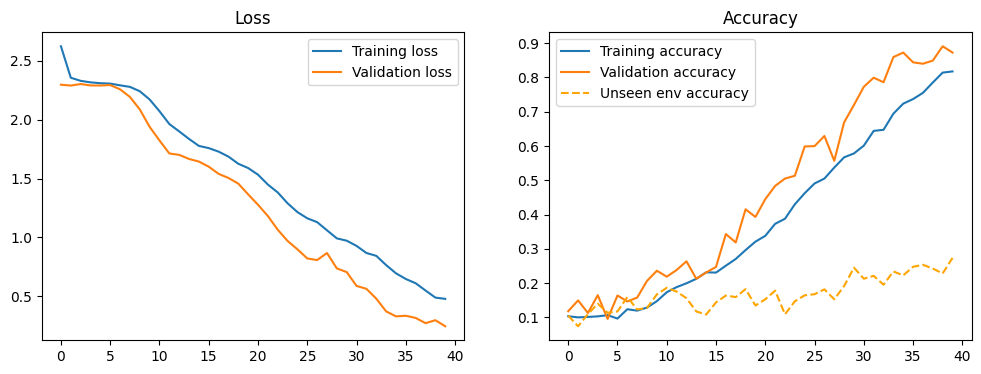

Epoch [41/1200], Train Loss: 0.4546, Train Acc: 0.8306, Val Loss: 0.2081, Val Acc: 0.9358, Unseen Acc: 0.2665
  ✓ Best model saved with validation accuracy: 0.9358
Epoch [42/1200], Train Loss: 0.4342, Train Acc: 0.8349, Val Loss: 0.2252, Val Acc: 0.9012, Unseen Acc: 0.2342
Epoch [43/1200], Train Loss: 0.3896, Train Acc: 0.8650, Val Loss: 0.1259, Val Acc: 0.9593, Unseen Acc: 0.2684
  ✓ Best model saved with validation accuracy: 0.9593
Epoch [44/1200], Train Loss: 0.3189, Train Acc: 0.8966, Val Loss: 0.1006, Val Acc: 0.9715, Unseen Acc: 0.2761
  ✓ Best model saved with validation accuracy: 0.9715
Epoch [45/1200], Train Loss: 0.3112, Train Acc: 0.9018, Val Loss: 0.1336, Val Acc: 0.9521, Unseen Acc: 0.2658
Epoch [46/1200], Train Loss: 0.2900, Train Acc: 0.9147, Val Loss: 0.1142, Val Acc: 0.9644, Unseen Acc: 0.2639
Epoch [47/1200], Train Loss: 0.2464, Train Acc: 0.9240, Val Loss: 0.0903, Val Acc: 0.9674, Unseen Acc: 0.2426
Epoch [48/1200], Train Loss: 0.2625, Train Acc: 0.9240, Val Loss: 0.

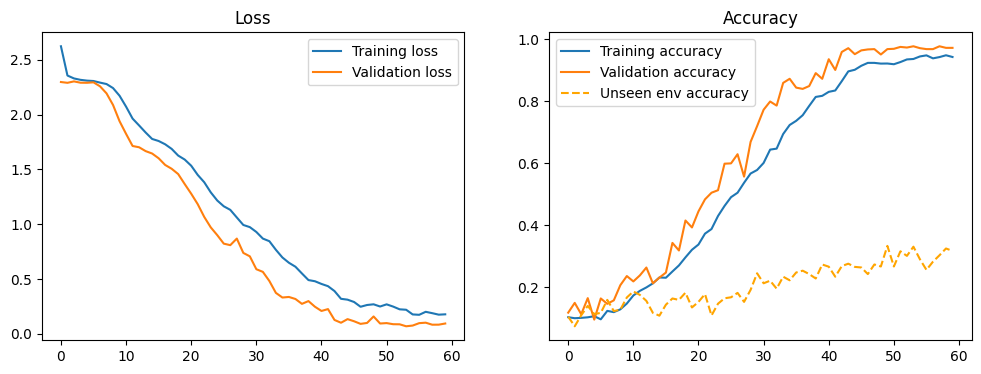

Epoch [61/1200], Train Loss: 0.1918, Train Acc: 0.9480, Val Loss: 0.1089, Val Acc: 0.9664, Unseen Acc: 0.3439
Epoch [62/1200], Train Loss: 0.1914, Train Acc: 0.9445, Val Loss: 0.0872, Val Acc: 0.9715, Unseen Acc: 0.2032
Epoch [63/1200], Train Loss: 0.1806, Train Acc: 0.9471, Val Loss: 0.0779, Val Acc: 0.9756, Unseen Acc: 0.2819
Epoch [64/1200], Train Loss: 0.1710, Train Acc: 0.9486, Val Loss: 0.0805, Val Acc: 0.9756, Unseen Acc: 0.2806
Epoch [65/1200], Train Loss: 0.1513, Train Acc: 0.9553, Val Loss: 0.1019, Val Acc: 0.9664, Unseen Acc: 0.3026
Epoch [66/1200], Train Loss: 0.1512, Train Acc: 0.9559, Val Loss: 0.0675, Val Acc: 0.9766, Unseen Acc: 0.3348
Epoch [67/1200], Train Loss: 0.1431, Train Acc: 0.9649, Val Loss: 0.0676, Val Acc: 0.9756, Unseen Acc: 0.3200
Epoch [68/1200], Train Loss: 0.1060, Train Acc: 0.9687, Val Loss: 0.0770, Val Acc: 0.9715, Unseen Acc: 0.3045
Epoch [69/1200], Train Loss: 0.0989, Train Acc: 0.9720, Val Loss: 0.0716, Val Acc: 0.9796, Unseen Acc: 0.3161
  ✓ Best m

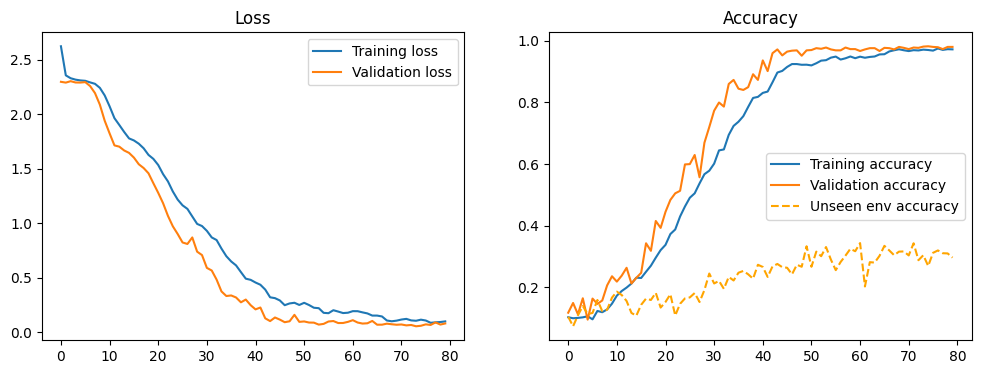

Epoch [81/1200], Train Loss: 0.1030, Train Acc: 0.9682, Val Loss: 0.0637, Val Acc: 0.9817, Unseen Acc: 0.3200
Epoch [82/1200], Train Loss: 0.0959, Train Acc: 0.9755, Val Loss: 0.0773, Val Acc: 0.9776, Unseen Acc: 0.3606
Epoch [83/1200], Train Loss: 0.1077, Train Acc: 0.9722, Val Loss: 0.0716, Val Acc: 0.9756, Unseen Acc: 0.3065
Epoch [84/1200], Train Loss: 0.0828, Train Acc: 0.9758, Val Loss: 0.0672, Val Acc: 0.9796, Unseen Acc: 0.3219
Epoch [85/1200], Train Loss: 0.0750, Train Acc: 0.9763, Val Loss: 0.0569, Val Acc: 0.9807, Unseen Acc: 0.3245
Epoch [86/1200], Train Loss: 0.0871, Train Acc: 0.9755, Val Loss: 0.0604, Val Acc: 0.9796, Unseen Acc: 0.3142
Epoch [87/1200], Train Loss: 0.0894, Train Acc: 0.9763, Val Loss: 0.0515, Val Acc: 0.9837, Unseen Acc: 0.3181
  ✓ Best model saved with validation accuracy: 0.9837
Epoch [88/1200], Train Loss: 0.0795, Train Acc: 0.9787, Val Loss: 0.0526, Val Acc: 0.9817, Unseen Acc: 0.3297
Epoch [89/1200], Train Loss: 0.0599, Train Acc: 0.9816, Val Loss: 

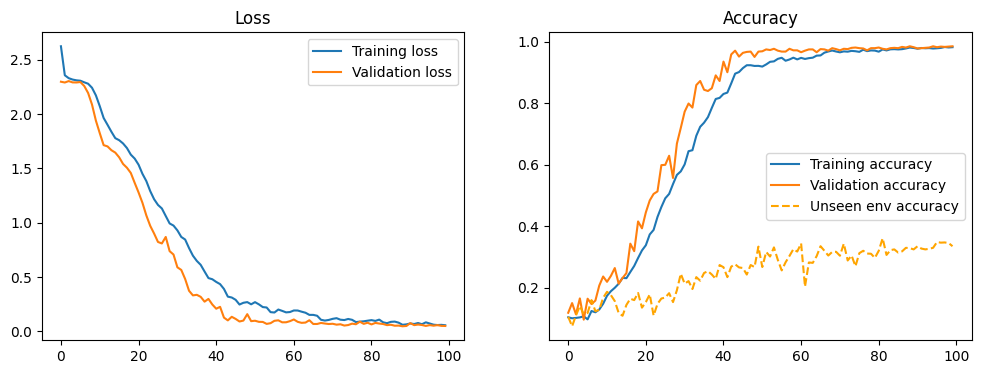

Epoch [101/1200], Train Loss: 0.0587, Train Acc: 0.9813, Val Loss: 0.0488, Val Acc: 0.9847, Unseen Acc: 0.3303
Epoch [102/1200], Train Loss: 0.0625, Train Acc: 0.9819, Val Loss: 0.0503, Val Acc: 0.9857, Unseen Acc: 0.3368
Epoch [103/1200], Train Loss: 0.0584, Train Acc: 0.9822, Val Loss: 0.0558, Val Acc: 0.9807, Unseen Acc: 0.3471
Epoch [104/1200], Train Loss: 0.0610, Train Acc: 0.9828, Val Loss: 0.0613, Val Acc: 0.9807, Unseen Acc: 0.3490
Epoch [105/1200], Train Loss: 0.0467, Train Acc: 0.9839, Val Loss: 0.0548, Val Acc: 0.9837, Unseen Acc: 0.3419
Epoch [106/1200], Train Loss: 0.0582, Train Acc: 0.9822, Val Loss: 0.0557, Val Acc: 0.9837, Unseen Acc: 0.3335
Epoch [107/1200], Train Loss: 0.0527, Train Acc: 0.9845, Val Loss: 0.0509, Val Acc: 0.9827, Unseen Acc: 0.3497
Epoch [108/1200], Train Loss: 0.0558, Train Acc: 0.9822, Val Loss: 0.0574, Val Acc: 0.9837, Unseen Acc: 0.3529
Epoch [109/1200], Train Loss: 0.0529, Train Acc: 0.9860, Val Loss: 0.0525, Val Acc: 0.9857, Unseen Acc: 0.3568
E

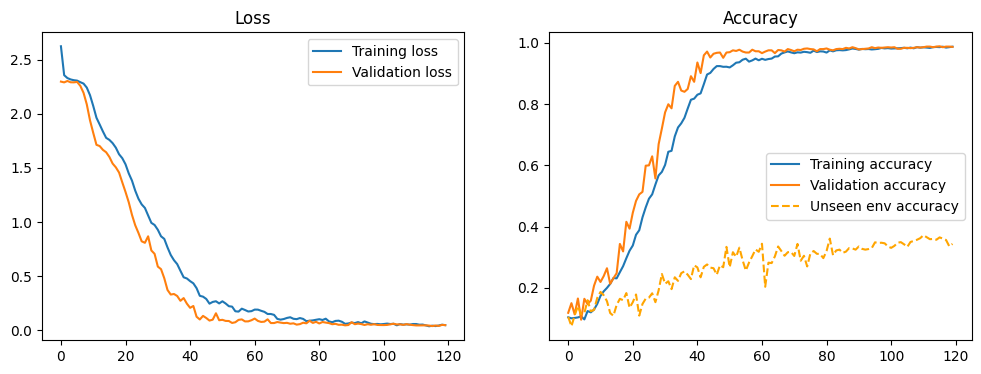

Epoch [121/1200], Train Loss: 0.0431, Train Acc: 0.9880, Val Loss: 0.0461, Val Acc: 0.9878, Unseen Acc: 0.3529
Epoch [122/1200], Train Loss: 0.0484, Train Acc: 0.9845, Val Loss: 0.0482, Val Acc: 0.9847, Unseen Acc: 0.3439
Epoch [123/1200], Train Loss: 0.0471, Train Acc: 0.9848, Val Loss: 0.0502, Val Acc: 0.9847, Unseen Acc: 0.3484
Epoch [124/1200], Train Loss: 0.0431, Train Acc: 0.9880, Val Loss: 0.0527, Val Acc: 0.9847, Unseen Acc: 0.3458
Epoch [125/1200], Train Loss: 0.0528, Train Acc: 0.9860, Val Loss: 0.0449, Val Acc: 0.9857, Unseen Acc: 0.3555
Epoch [126/1200], Train Loss: 0.0489, Train Acc: 0.9863, Val Loss: 0.0432, Val Acc: 0.9868, Unseen Acc: 0.3477
Epoch [127/1200], Train Loss: 0.0453, Train Acc: 0.9851, Val Loss: 0.0431, Val Acc: 0.9898, Unseen Acc: 0.3445
  ✓ Best model saved with validation accuracy: 0.9898
Epoch [128/1200], Train Loss: 0.0320, Train Acc: 0.9892, Val Loss: 0.0443, Val Acc: 0.9888, Unseen Acc: 0.3387
Epoch [129/1200], Train Loss: 0.0461, Train Acc: 0.9877, V

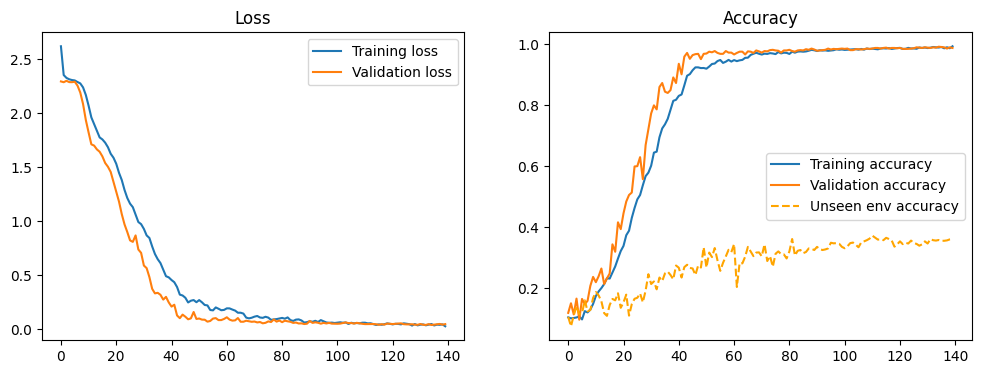

Epoch [141/1200], Train Loss: 0.0384, Train Acc: 0.9915, Val Loss: 0.0407, Val Acc: 0.9908, Unseen Acc: 0.3555
Epoch [142/1200], Train Loss: 0.0315, Train Acc: 0.9904, Val Loss: 0.0396, Val Acc: 0.9898, Unseen Acc: 0.3484
Epoch [143/1200], Train Loss: 0.0500, Train Acc: 0.9857, Val Loss: 0.0440, Val Acc: 0.9868, Unseen Acc: 0.3452
Epoch [144/1200], Train Loss: 0.0344, Train Acc: 0.9889, Val Loss: 0.0401, Val Acc: 0.9888, Unseen Acc: 0.3484
Epoch [145/1200], Train Loss: 0.0363, Train Acc: 0.9892, Val Loss: 0.0484, Val Acc: 0.9868, Unseen Acc: 0.3368
Epoch [146/1200], Train Loss: 0.0319, Train Acc: 0.9930, Val Loss: 0.0433, Val Acc: 0.9878, Unseen Acc: 0.3406
Epoch [147/1200], Train Loss: 0.0424, Train Acc: 0.9901, Val Loss: 0.0412, Val Acc: 0.9868, Unseen Acc: 0.3458
Epoch [148/1200], Train Loss: 0.0304, Train Acc: 0.9909, Val Loss: 0.0424, Val Acc: 0.9888, Unseen Acc: 0.3471
Epoch [149/1200], Train Loss: 0.0309, Train Acc: 0.9912, Val Loss: 0.0445, Val Acc: 0.9888, Unseen Acc: 0.3477
E

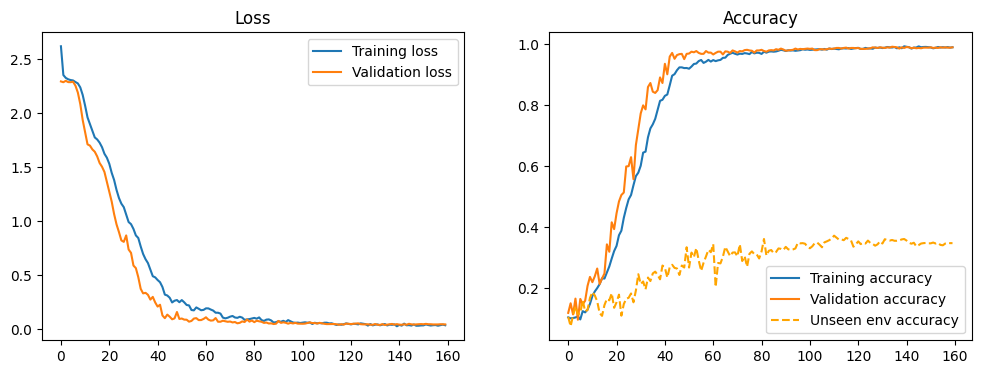

Epoch [161/1200], Train Loss: 0.0308, Train Acc: 0.9904, Val Loss: 0.0441, Val Acc: 0.9878, Unseen Acc: 0.3490
Epoch [162/1200], Train Loss: 0.0375, Train Acc: 0.9915, Val Loss: 0.0461, Val Acc: 0.9878, Unseen Acc: 0.3471
Epoch [163/1200], Train Loss: 0.0316, Train Acc: 0.9912, Val Loss: 0.0425, Val Acc: 0.9898, Unseen Acc: 0.3458
Epoch [164/1200], Train Loss: 0.0292, Train Acc: 0.9901, Val Loss: 0.0437, Val Acc: 0.9888, Unseen Acc: 0.3452
Epoch [165/1200], Train Loss: 0.0254, Train Acc: 0.9915, Val Loss: 0.0418, Val Acc: 0.9898, Unseen Acc: 0.3452
Epoch [166/1200], Train Loss: 0.0331, Train Acc: 0.9909, Val Loss: 0.0417, Val Acc: 0.9888, Unseen Acc: 0.3497
Epoch [167/1200], Train Loss: 0.0339, Train Acc: 0.9907, Val Loss: 0.0402, Val Acc: 0.9898, Unseen Acc: 0.3503
Epoch [168/1200], Train Loss: 0.0308, Train Acc: 0.9921, Val Loss: 0.0435, Val Acc: 0.9898, Unseen Acc: 0.3497
Epoch [169/1200], Train Loss: 0.0351, Train Acc: 0.9924, Val Loss: 0.0425, Val Acc: 0.9888, Unseen Acc: 0.3529
E

KeyboardInterrupt: 

In [29]:

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
unseen_accuracies = []
best_val_acc = 0.0

# Initialize early stopping
early_stopping = EarlyStopping(patience=early_stopping_patience, 
                                min_delta=early_stopping_min_delta, 
                                mode='min')  # Monitor validation loss

print(f"🚀 Starting training with early stopping:")
print(f"   • Max epochs: {max_epochs}")
print(f"   • Early stopping patience: {early_stopping_patience} epochs")
print(f"   • Min delta: {early_stopping_min_delta}")
print(f"   • Monitoring: Validation Loss")
print(f"   • Unseen env: {unseen_data_path.split('/')[-1]}\n")

for epoch in range(max_epochs):
    model.train()
    correct = 0
    total = 0
    epoch_loss = 0

    for inputs, labels in train_dataloader:
        inputs = inputs.to(device)
        labels = torch.squeeze(labels).to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = cost(outputs, labels)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        epoch_loss += loss.item()

    train_acc = correct / total
    avg_train_loss = epoch_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    with torch.no_grad():
        # ── Validation ────────────────────────────────────────────────────────
        correct = 0
        total = 0
        val_loss = 0

        for inputs, labels in val_dataloader:
            inputs = inputs.to(device)
            labels = torch.squeeze(labels).to(device)
            outputs = model(inputs)

            loss = cost(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        val_acc = correct / total
        avg_val_loss = val_loss / len(val_dataloader)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        # ── Unseen environment ────────────────────────────────────────────────
        unseen_correct = 0
        unseen_total = 0

        for inputs, labels in unseen_dataloader:
            inputs = inputs.to(device)
            labels = torch.squeeze(labels).to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            unseen_total += labels.size(0)
            unseen_correct += (predicted == labels).sum().item()

        unseen_acc = unseen_correct / unseen_total
        unseen_accuracies.append(unseen_acc)

    scheduler.step(avg_val_loss)

    print(f"Epoch [{epoch + 1}/{max_epochs}], "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}, "
          f"Unseen Acc: {unseen_acc:.4f}")

    if epoch != 0 and (epoch % 20 == 19):
        plot_results(train_losses, train_accuracies, val_losses, val_accuracies, unseen_accuracies)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_model(model, best_model_path)
        print(f"  ✓ Best model saved with validation accuracy: {val_acc:.4f}")

    # Early stopping check
    if early_stopping(avg_val_loss):
        print(f"\n🛑 Early stopping triggered after {epoch + 1} epochs")
        print(f"   • No improvement in validation loss for {early_stopping.patience} epochs")
        print(f"   • Best validation loss: {early_stopping.best_score:.4f}")
        print(f"   • Best validation accuracy: {best_val_acc:.4f}")
        break

# Final summary
if not early_stopping.early_stop:
    print(f"\n✅ Training completed - reached maximum epochs ({max_epochs})")
else:
    print(f"\n✅ Training completed - early stopping at epoch {epoch + 1}")

print(f"   • Total epochs trained  : {len(train_losses)}")
print(f"   • Best validation acc   : {best_val_acc:.4f}")
print(f"   • Final validation acc  : {val_accuracies[-1]:.4f}")
print(f"   • Final unseen env acc  : {unseen_accuracies[-1]:.4f}")


In [ ]:
save_model(model, model_path)

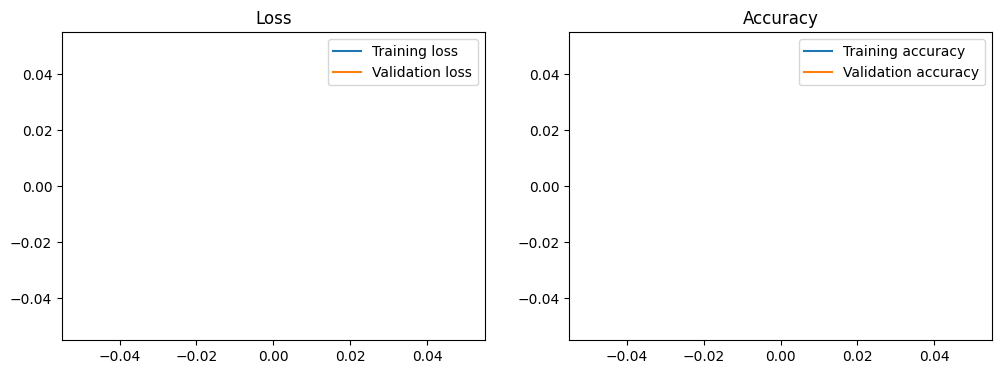


📊 Training Summary:


ValueError: max() iterable argument is empty

In [ ]:

# Plot final training results
plot_results(train_losses, train_accuracies, val_losses, val_accuracies, unseen_accuracies)

print(f"\n📊 Training Summary:")
print(f"   • Best validation acc   : {max(val_accuracies):.4f}")
print(f"   • Last validation acc   : {val_accuracies[-1]:.4f}")
print(f"   • Last unseen env acc   : {unseen_accuracies[-1]:.4f}")
print(f"   • Epochs trained        : {len(val_accuracies)}")


---

## 🔧 Fine-Tuning

For fine-tuning a trained model on production/deployment data, use:

**[CNN-FineTuning.ipynb](CNN-FineTuning.ipynb)**

This separate notebook allows you to:
- Load a pre-trained model from this notebook
- Fine-tune on small production datasets  
- Freeze early layers for better performance on small data
- Compare original vs fine-tuned model accuracy

---

### Results

In [ ]:
model.load_state_dict(torch.load(best_model_path))
model.to(device)
model.eval()

CNN(
  (conv1): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout2d(p=0.25, inplace=False)
  (conv2): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

In [ ]:
digits = [str(digit) for digit in range(10)]
alphabet = [chr(ascii_code) for ascii_code in range(ord('A'), ord('Z') + 1)]
all_characters = digits + alphabet
label_dict = {i: all_characters[i] for i in range(len(all_characters))}
print(label_dict)

{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'A', 11: 'B', 12: 'C', 13: 'D', 14: 'E', 15: 'F', 16: 'G', 17: 'H', 18: 'I', 19: 'J', 20: 'K', 21: 'L', 22: 'M', 23: 'N', 24: 'O', 25: 'P', 26: 'Q', 27: 'R', 28: 'S', 29: 'T', 30: 'U', 31: 'V', 32: 'W', 33: 'X', 34: 'Y', 35: 'Z'}


In [ ]:
def predict(data_loader):
    original_labels = []
    predicted_labels = []
    correct = 0
    total = 0

    model.eval()

    for inputs, labels in data_loader:
        inputs = inputs.to(device)
        labels = torch.squeeze(labels).to(device)
        outputs = model(inputs)

        _, predicted = torch.max(outputs.data, 1)

        original_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predicted.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    prediction_df = pd.DataFrame({
        "predicted_labels": [label_dict[pred] for pred in predicted_labels],
        "true_labels": [label_dict[label] for label in original_labels]
    })

    print(f"Test Accuracy: {correct/total}")
    pd.set_option('display.max_rows', None)
    pd.set_option("display.max_columns", None)
    display(prediction_df.T)

    print(metrics.accuracy_score(original_labels, predicted_labels))
    print(metrics.classification_report(original_labels, predicted_labels))

    return confusion_matrix(original_labels, predicted_labels)

### Test accuracy

In [ ]:
cm = predict(test_dataloader)

Test Accuracy: 0.9835051546391752


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484
predicted_labels,9,2,4,3,8,7,3,7,7,0,4,5,9,0,6,4,5,5,3,5,2,0,6,6,3,6,5,1,0,7,0,6,3,0,4,5,0,2,8,7,4,7,1,5,0,7,9,8,1,8,1,9,9,8,3,9,9,6,8,4,4,5,7,1,6,8,8,8,6,0,0,8,4,5,2,9,6,6,9,2,8,5,1,5,9,9,6,8,6,2,6,8,5,5,9,9,4,5,1,1,3,6,5,1,2,4,2,0,8,1,3,7,0,3,1,9,4,7,5,1,3,6,3,4,3,1,3,3,6,1,1,2,2,6,8,6,3,3,9,3,2,3,6,6,3,3,7,4,4,7,7,4,6,4,9,7,5,5,3,5,3,4,3,9,3,6,7,4,5,5,0,6,7,1,1,3,1,2,8,2,3,3,3,3,2,9,3,3,2,9,5,8,5,1,9,8,0,9,7,0,3,0,7,0,8,1,2,6,4,0,5,7,7,9,0,5,0,5,4,9,8,7,4,4,5,1,4,7,0,5,8,7,5,2,1,0,3,7,3,1,3,8,0,1,4,2,7,6,2,7,7,9,4,8,4,0,9,4,6,4,9,3,2,0,2,4,4,1,6,2,7,5,2,4,7,8,0,6,4,6,9,7,2,9,5,2,7,0,2,9,6,6,0,0,7,7,2,2,9,8,8,4,0,6,8,3,4,6,1,3,0,1,2,9,8,8,7,5,5,6,4,1,2,5,4,8,4,2,9,9,8,0,3,7,2,1,4,2,6,3,0,5,8,0,7,7,7,2,0,2,1,2,9,2,6,8,8,2,9,8,8,7,0,1,5,5,0,3,0,3,6,9,7,6,2,9,6,7,1,6,8,4,4,7,1,3,5,8,2,2,3,8,0,5,5,3,7,6,4,7,1,9,8,1,2,5,6,9,7,8,3,4,9,1,1,2,9,9,3,4,2,9,0,6,5,8,0,0,7,8,1,5,2,9,4,6,5,7,3,0,4,4,1,3,2,6,8,2,1,2,7,0,5,9,2,2,5,5,6,1,9,5,7,3,6,8,5,9,4,0,0,7,6,7,9,0,6,8,5,0,0,4,0,8,5
true_labels,9,2,4,3,8,7,3,7,7,0,4,5,9,0,6,4,5,5,3,5,2,0,6,6,3,6,5,1,0,7,0,6,3,0,4,5,0,2,8,7,4,7,1,5,0,7,9,8,1,8,1,9,9,8,3,9,9,6,8,4,4,5,7,1,6,8,8,8,6,0,0,8,4,5,2,9,6,6,9,2,8,5,1,5,9,9,6,8,6,2,6,8,5,5,9,9,4,5,1,1,3,6,5,1,2,4,2,0,8,1,3,7,0,3,1,9,4,7,5,1,3,6,1,4,3,1,3,3,6,1,1,2,2,6,8,6,3,3,9,3,2,3,6,6,3,3,7,4,4,7,7,4,6,4,9,7,5,5,3,5,3,4,8,9,3,6,7,4,5,5,0,6,7,1,1,3,1,2,8,2,3,3,3,3,2,9,3,3,2,9,5,8,5,9,9,8,0,9,7,0,3,0,7,0,8,1,2,6,4,0,5,7,7,9,0,5,0,5,4,9,8,7,4,4,5,1,4,8,0,5,8,7,5,2,1,0,3,7,3,1,3,8,0,1,4,2,7,6,2,7,7,9,4,8,4,0,9,4,6,4,9,3,2,0,2,4,4,1,6,2,7,5,2,4,7,8,0,6,4,6,9,7,2,9,5,2,7,0,2,9,6,6,0,0,7,7,2,2,9,8,8,4,0,6,8,3,4,6,6,3,0,1,2,9,8,8,7,5,5,6,4,1,2,5,4,8,4,2,9,9,8,0,3,7,2,1,4,2,6,3,0,5,8,0,7,7,7,2,0,2,1,2,9,2,6,8,8,2,9,8,8,7,0,1,5,5,0,3,0,3,6,9,7,6,2,9,6,7,1,6,8,4,4,7,1,3,5,8,2,2,3,8,0,0,5,3,7,6,4,7,1,9,8,1,2,5,6,9,7,8,3,4,9,1,1,2,9,9,3,4,2,9,0,6,5,8,0,0,7,8,1,5,2,9,4,6,5,7,3,0,4,4,1,3,2,6,8,2,1,2,7,0,5,9,2,2,5,5,6,1,9,5,7,3,6,8,5,9,4,0,0,7,6,7,9,0,6,8,3,0,0,4,4,8,5


0.9835051546391752
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        50
           1       0.95      0.97      0.96        40
           2       1.00      1.00      1.00        50
           3       0.96      0.98      0.97        49
           4       1.00      0.98      0.99        49
           5       0.96      1.00      0.98        49
           6       1.00      0.98      0.99        50
           7       0.98      1.00      0.99        50
           8       1.00      0.96      0.98        49
           9       1.00      0.98      0.99        49

    accuracy                           0.98       485
   macro avg       0.98      0.98      0.98       485
weighted avg       0.98      0.98      0.98       485



### Confusion matrix

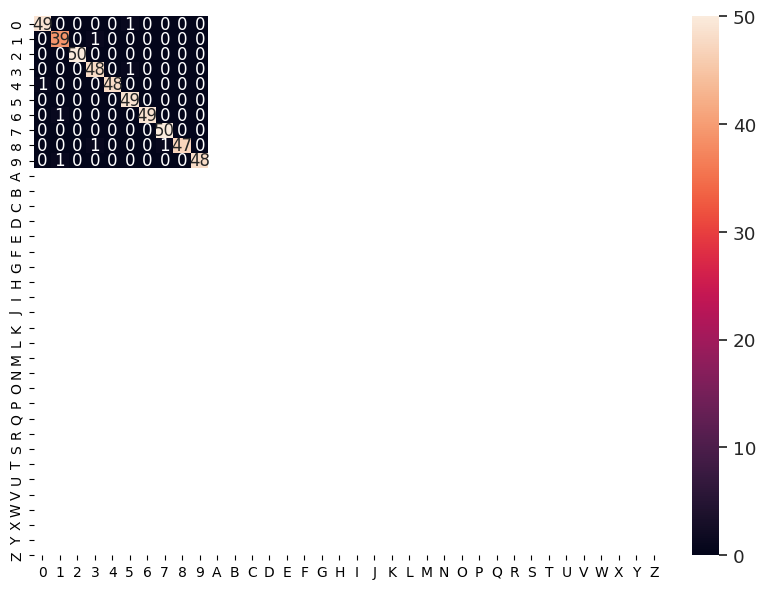

In [ ]:
fig, ax = plt.subplots(figsize=(10,7))
sns.set(font_scale=1.2)
ax = sns.heatmap(cm,
                annot=True,
                fmt='g',
                xticklabels=all_characters,
                yticklabels=all_characters,
                annot_kws={"size": 12}
                )
plt.show()

---

## 🎙️ Gradio Web Interface

Interactive web interface for testing the trained model with real audio recordings or uploaded files.

In [ ]:
import sys
import os
best_model_path = "model/CNN-Best.pkl"
# Add inference module to path
inference_path = os.path.join(os.getcwd(), 'inference')
if inference_path not in sys.path:
    sys.path.insert(0, inference_path)

from app_gradio import create_gradio_interface

# Create the Gradio interface with the best model
interface = create_gradio_interface(model_path=best_model_path)

print("✅ Gradio interface created successfully!")
print(f"   Model: {best_model_path}")

/root/minor/keyboard_sound/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading model from: model/CNN-Best.pkl
Device: CUDA
⚠ Warning: Unknown model type, defaulting to CNN
First 5 keys: ['conv1.conv.0.weight', 'conv1.conv.0.bias', 'conv1.conv.1.weight', 'conv1.conv.1.bias', 'conv1.conv.1.running_mean']
Creating CNN model with 36 classes...
Using alphanumeric labels (0-9, a-z)
Model parameters: 4,856,932
Model test successful - output shape: torch.Size([1, 36])
✓ Model loaded successfully!

✅ Gradio interface created successfully!
   Model: model/CNN-Best.pkl


In [ ]:
# Launch the Gradio interface
# Options:
#   share=True  : Create a public shareable link (requires internet)
#   share=False : Local access only (default)
#   server_port=7860 : Specify a custom port

print("\n🚀 Launching Gradio web interface...")
print("   Once launched, the interface will be available at the URL shown below.")
print("   Use it to test the model with real-time audio recording or file uploads.\n")

# Launch with auto-reload disabled in notebook environment
interface.launch(
    share=True,
    inline=False,  # Display inline in Jupyter notebook
    quiet=True,   # Suppress Gradio logs for cleaner output
)


🚀 Launching Gradio web interface...
   Once launched, the interface will be available at the URL shown below.
   Use it to test the model with real-time audio recording or file uploads.

* Running on public URL: https://7502c3ab217e3896f6.gradio.live
